In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/Extras/LPD")
from lpd_resnet18 import LPDResNet18

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

ERROR! Session/line number was not unique in database. History logging moved to new session 3


In [4]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
train_ds = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds = filter_by_elev(meas_ds, {17})

In [6]:
class MultiTaskDataset(Dataset):
    def __init__(self, dataset, sample_to_azimuth_idx, vehicle_classes, azimuth_classes):
        self.dataset = dataset
        self.sample_to_azimuth_idx = sample_to_azimuth_idx
        self.vehicle_classes = vehicle_classes
        self.azimuth_classes = azimuth_classes
        # keep only samples that have a valid azimuth label
        self.valid_indices = [i for i in range(len(dataset)) if i in sample_to_azimuth_idx]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]
        image, vehicle_label = self.dataset[original_idx]
        azimuth_label = self.sample_to_azimuth_idx[original_idx]
        return image, vehicle_label, azimuth_label

    @property
    def samples(self):
        return [
            (self.dataset.samples[i][0], self.dataset.samples[i][1], self.sample_to_azimuth_idx[i])
            for i in self.valid_indices
        ]

In [7]:
def build_global_bin_to_label(*datasets, bin_width=10):
    """Step 1: scan all provided datasets, return a fixed bin_to_label map + azimuth_classes."""
    seen_bins = set()
    for ds in datasets:
        for path, _ in ds.samples:
            az = parse_metadata(path)['azim']
            if az is not None:
                raw_bin = (az // bin_width) * bin_width
                seen_bins.add(raw_bin)

    sorted_bins = sorted(seen_bins)
    bin_to_label = {b: i for i, b in enumerate(sorted_bins)}
    azimuth_classes = [f"az{b}" for b in sorted_bins]
    return bin_to_label, azimuth_classes


def assign_azimuth_labels(dataset, bin_to_label, bin_width=10):
    """Step 2: apply a fixed bin_to_label map to one split's own samples/indices."""
    sample_to_azimuth_idx = {}
    for idx, (path, _) in enumerate(dataset.samples):
        az = parse_metadata(path)['azim']
        if az is None:
            continue
        raw_bin = (az // bin_width) * bin_width
        sample_to_azimuth_idx[idx] = bin_to_label[raw_bin]
    return sample_to_azimuth_idx

In [8]:
bin_to_label, azimuth_classes = build_global_bin_to_label(train_ds, valid_ds, test_ds, bin_width=10)

train_azimuth_map = assign_azimuth_labels(train_ds, bin_to_label)
valid_azimuth_map = assign_azimuth_labels(valid_ds, bin_to_label)
test_azimuth_map  = assign_azimuth_labels(test_ds, bin_to_label)

multitask_train_ds = MultiTaskDataset(train_ds, train_azimuth_map, train_ds.classes, azimuth_classes)
multitask_valid_ds = MultiTaskDataset(valid_ds, valid_azimuth_map, valid_ds.classes, azimuth_classes)
multitask_test_ds  = MultiTaskDataset(test_ds,  test_azimuth_map,  test_ds.classes,  azimuth_classes)

In [9]:
assert no_aug_synth_ds.classes == meas_ds.classes, "Vehicle class lists differ between synth and measured!"

In [10]:
print(len(valid_ds), len(valid_azimuth_map))  # should be close, not wildly different
print(len(test_ds), len(test_azimuth_map))

806 806
539 539


In [11]:
class MultiTaskResNet18(nn.Module):
    def __init__(self, num_vehicle_classes, num_azimuth_classes, dropout_p=0.4):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.trunk = nn.Sequential(*list(backbone.children())[:-1])  # everything except fc
        in_features = backbone.fc.in_features

        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_vehicle = nn.Linear(in_features, num_vehicle_classes)
        self.fc_azimuth = nn.Linear(in_features, num_azimuth_classes)

    def forward(self, x):
        feats = self.trunk(x).flatten(1)
        feats = self.dropout(feats)
        return self.fc_vehicle(feats), self.fc_azimuth(feats)

In [12]:
dataset_sizes = {
    "train": len(multitask_train_ds),
    "val": len(multitask_valid_ds),
    "test": len(multitask_test_ds)
}

num_vehicle_classes = len(multitask_train_ds.vehicle_classes)
num_azimuth_classes = len(multitask_train_ds.azimuth_classes)

In [13]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
vehicle_weight, azimuth_weight = 1.0, 1.0  # tune if one task dominates

train_loss, val_loss = [], []
train_vehicle_acc, val_vehicle_acc = [], []
train_azimuth_acc, val_azimuth_acc = [], []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
    
    dataloaders = {
        "train": DataLoader(multitask_train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(multitask_valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(multitask_test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }

    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    history = {
        "train_loss": [], "val_loss": [],
        "train_vehicle_acc": [], "val_vehicle_acc": [],
        "train_azimuth_acc": [], "val_azimuth_acc": []
    }

    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.trunk[0].weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_vehicle_corrects = 0
            running_azimuth_corrects = 0

            for inputs, vehicle_labels, azimuth_labels in dataloaders[phase]:
                inputs = inputs.to(device)
                vehicle_labels = vehicle_labels.to(device)
                azimuth_labels = azimuth_labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    vehicle_logits, azimuth_logits = model(inputs)
                    _, vehicle_preds = torch.max(vehicle_logits, 1)
                    _, azimuth_preds = torch.max(azimuth_logits, 1)

                    loss_vehicle = criterion(vehicle_logits, vehicle_labels)
                    loss_azimuth = criterion(azimuth_logits, azimuth_labels)
                    loss = vehicle_weight * loss_vehicle + azimuth_weight * loss_azimuth

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_vehicle_corrects += (vehicle_preds == vehicle_labels).sum().item()
                running_azimuth_corrects += (azimuth_preds == azimuth_labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_vehicle_acc = running_vehicle_corrects / dataset_sizes[phase]
            epoch_azimuth_acc = running_azimuth_corrects / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_vehicle_acc"].append(epoch_vehicle_acc)
            history[f"{phase}_azimuth_acc"].append(epoch_azimuth_acc)

            print(f"{phase} Loss: {epoch_loss:.10f} Vehicle Acc: {epoch_vehicle_acc:.10f} Azimuth Acc: {epoch_azimuth_acc:.10f}")

        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

    print("Training complete!")

    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_vehicle_acc.append(history["train_vehicle_acc"])
    val_vehicle_acc.append(history["val_vehicle_acc"])
    train_azimuth_acc.append(history["train_azimuth_acc"])
    val_azimuth_acc.append(history["val_azimuth_acc"])

    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/multitask/wo_aug/rn18_seed{seed}_b16.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_vehicle_acc = np.array(train_vehicle_acc)
val_vehicle_acc = np.array(val_vehicle_acc)
train_azimuth_acc = np.array(train_azimuth_acc)
val_azimuth_acc = np.array(val_azimuth_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 2.5847520527 Vehicle Acc: 0.5645161290 Azimuth Acc: 0.5297766749
val Loss: 6.8508754995 Vehicle Acc: 0.1439205955 Azimuth Acc: 0.1774193548
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.7241989204 Vehicle Acc: 0.9553349876 Azimuth Acc: 0.8387096774
val Loss: 3.5720309377 Vehicle Acc: 0.3213399504 Azimuth Acc: 0.3424317618
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.3388405115 Vehicle Acc: 0.9900744417 Azimuth Acc: 0.9305210918
val Loss: 3.2155872075 Vehicle Acc: 0.3486352357 Azimuth Acc: 0.5521091811
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.2109487377 Vehicle Acc: 0.9950372208 Azimuth Acc: 0.9528535980
val Loss: 4.8675400436 Vehicle Acc: 0.2431761787 Azimuth Acc: 0.4243176179
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.2334258505 Vehicle Acc: 0.9987593052 Azimuth Acc: 0.9429280397
val Loss: 3.8032146763 Vehicle Acc: 0.3312655087 Azimuth Acc: 0.4764267990
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.19

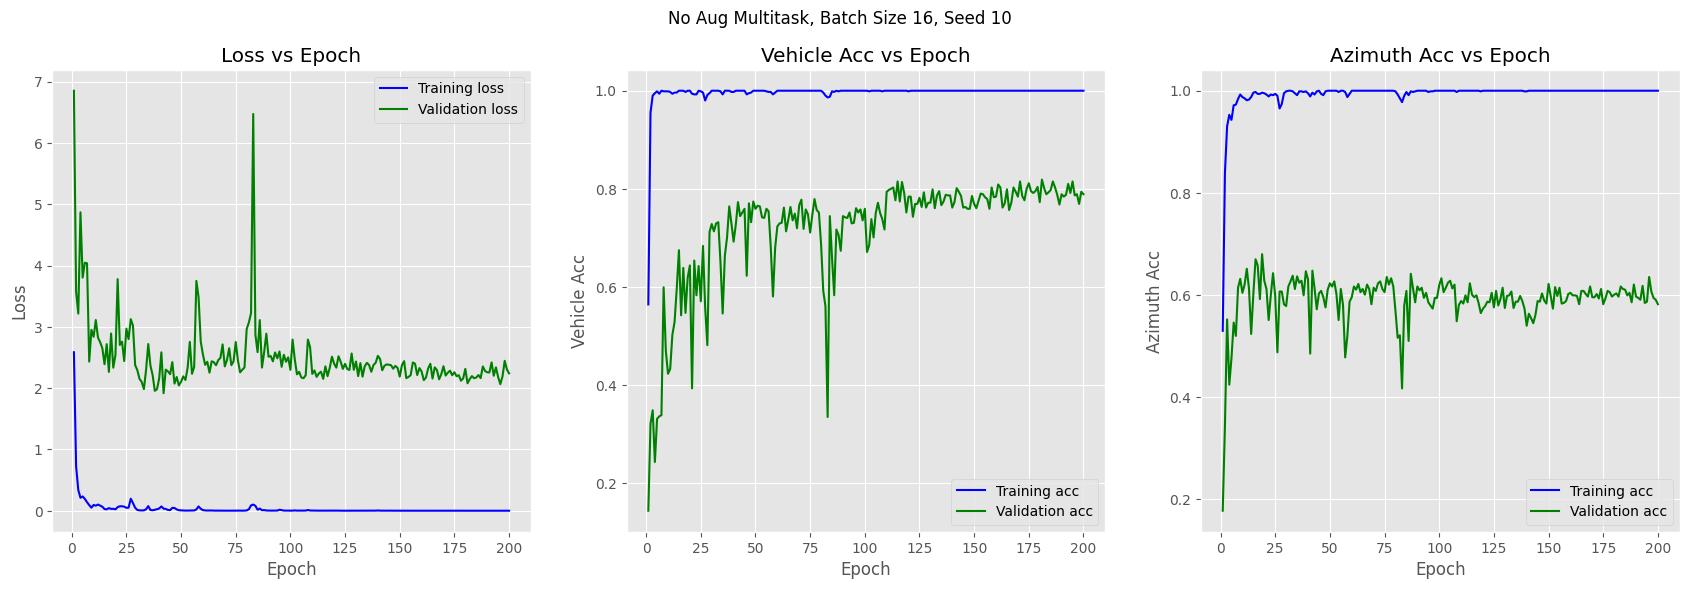

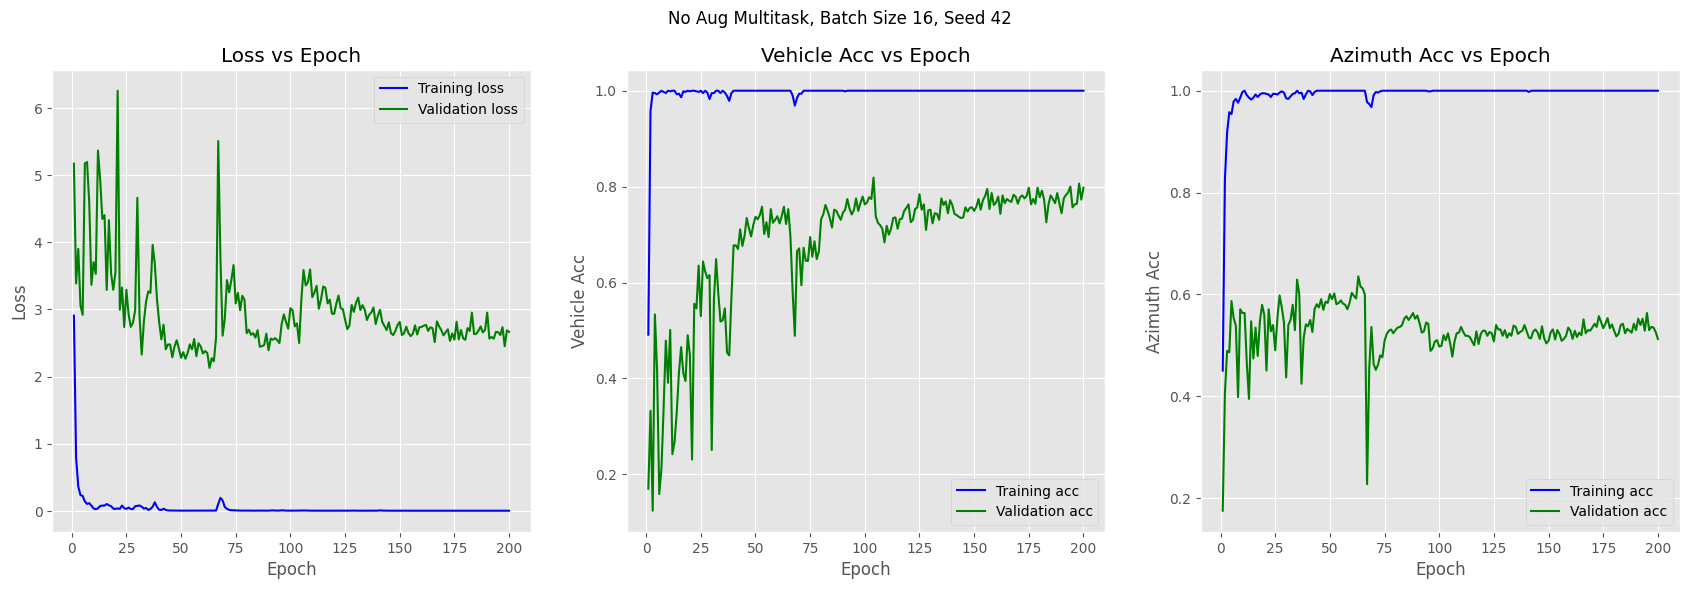

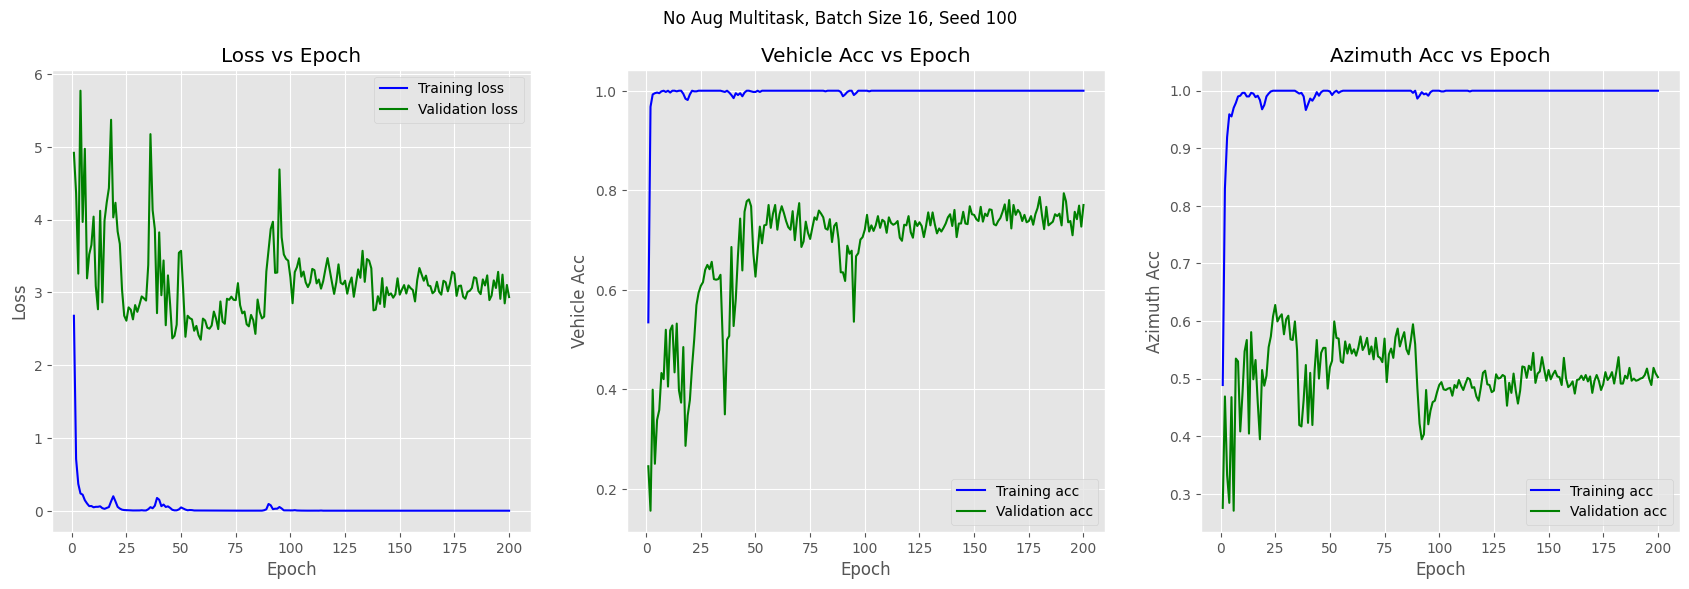

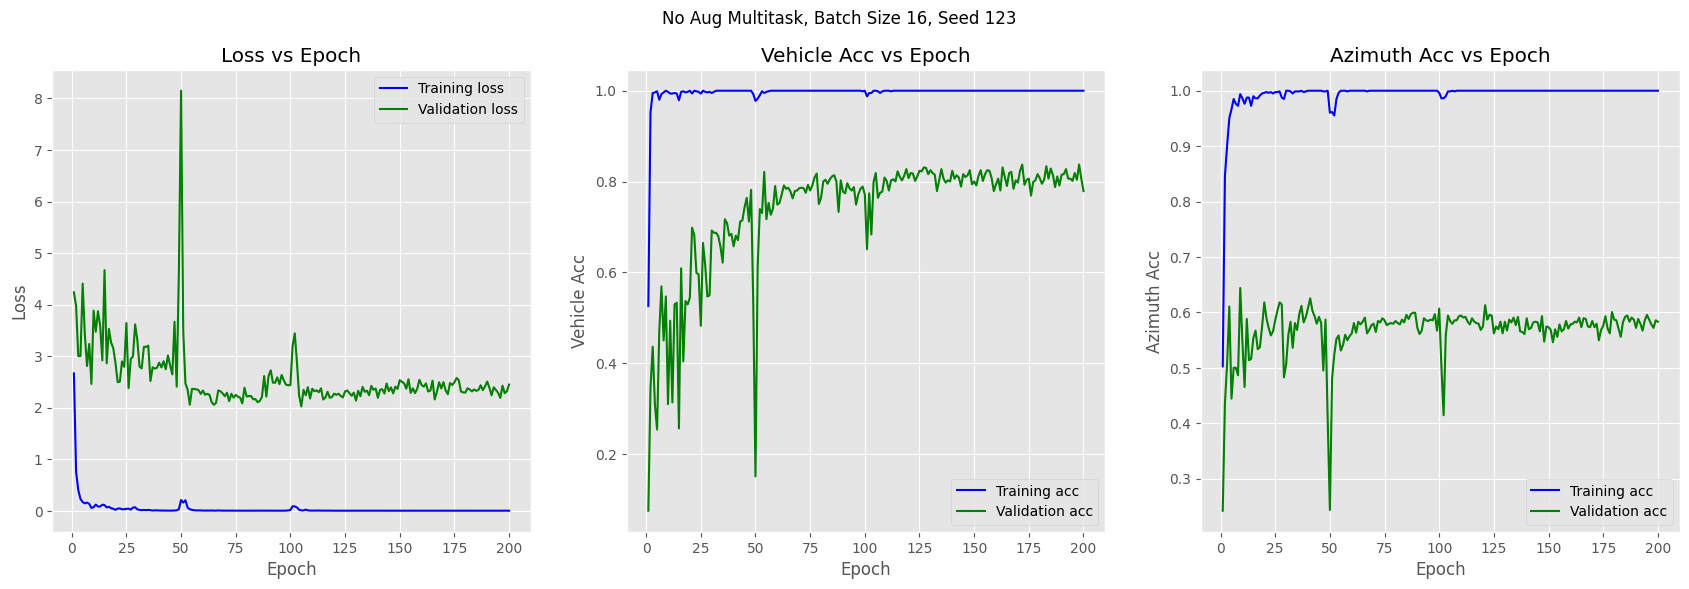

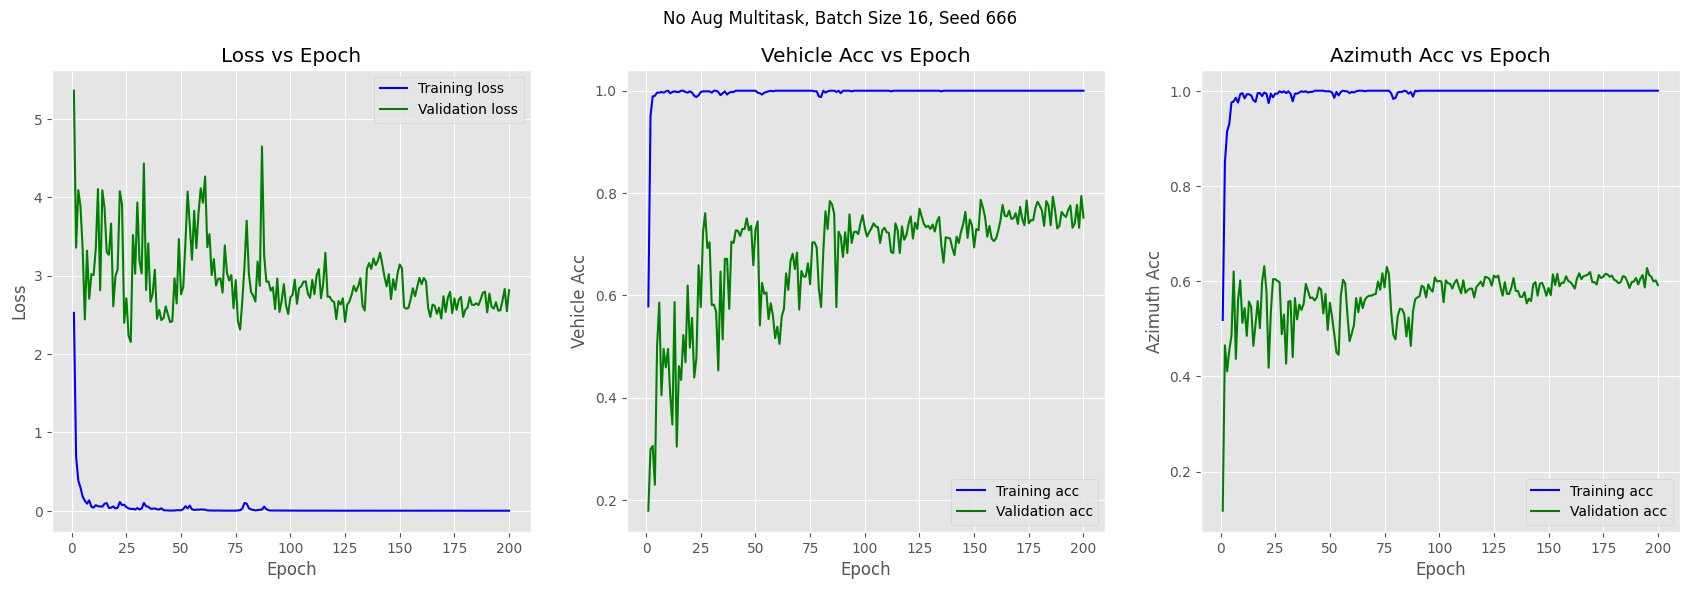

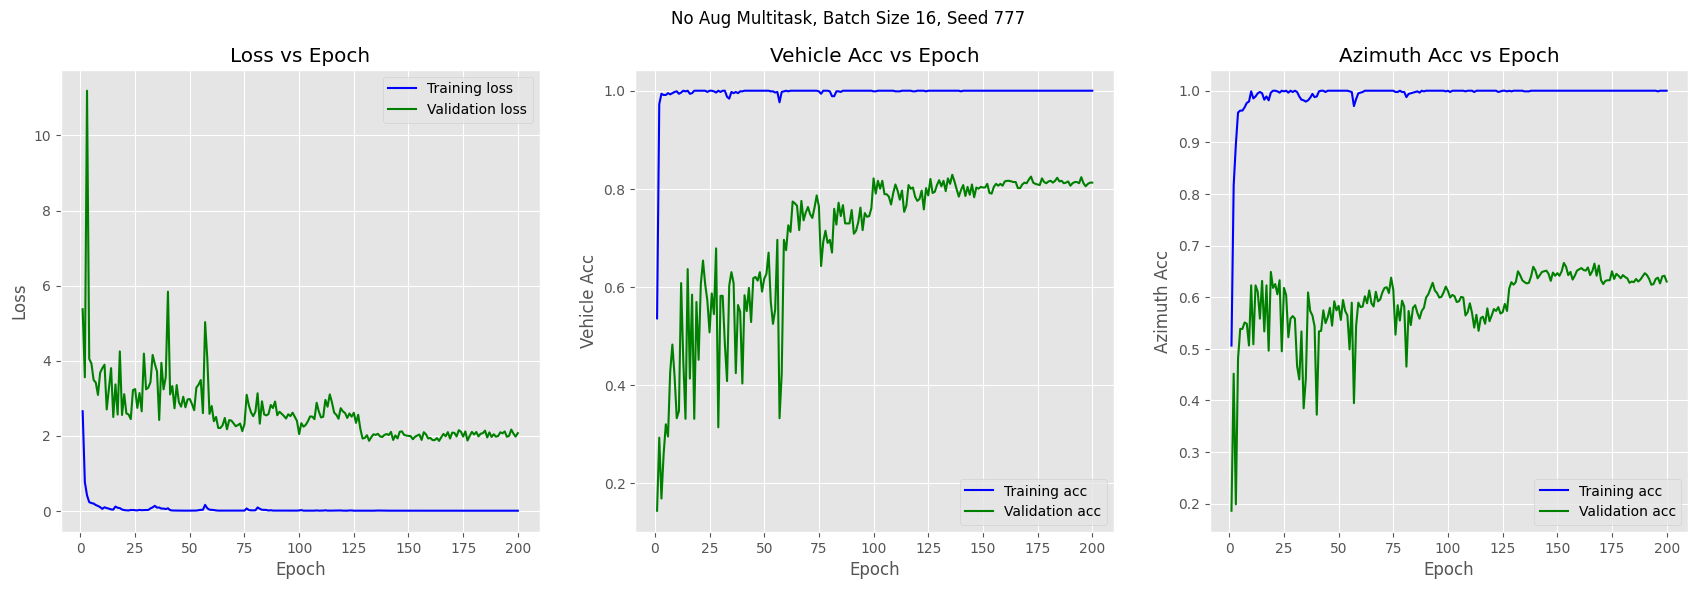

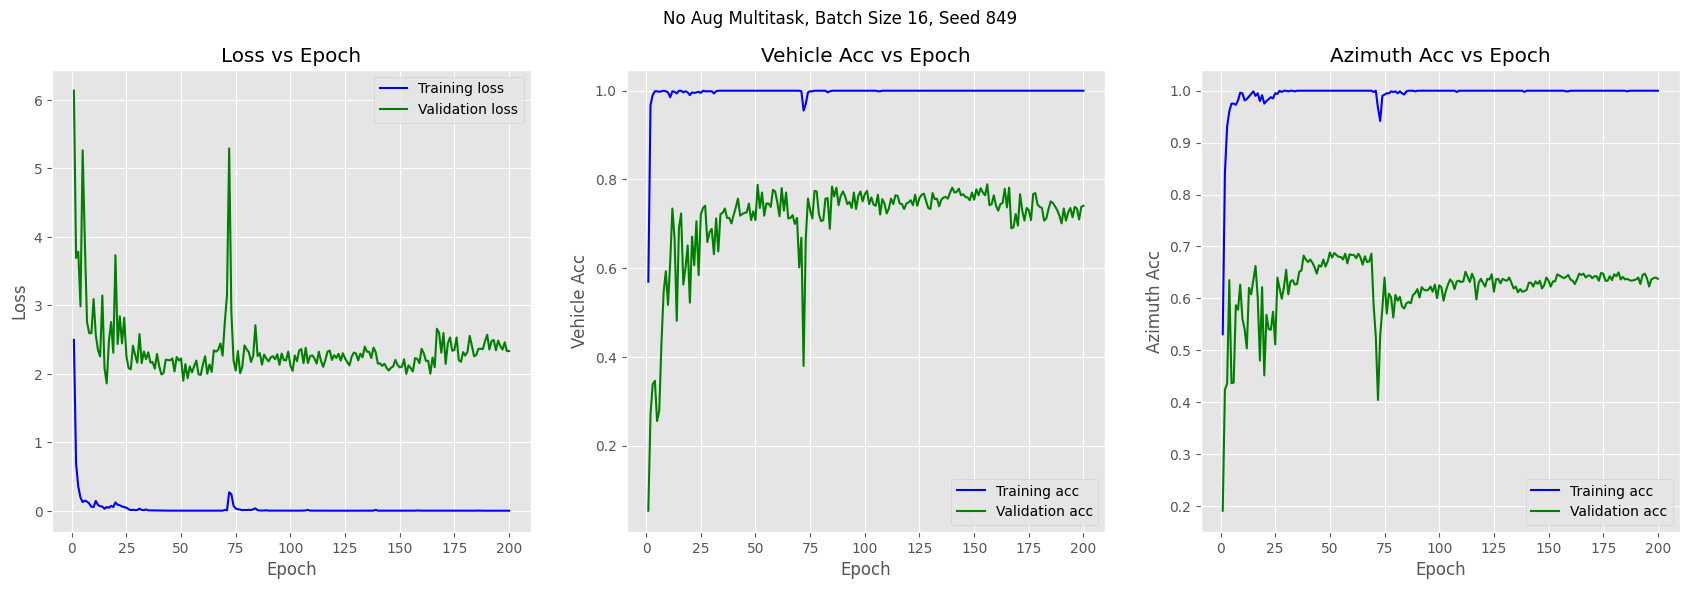

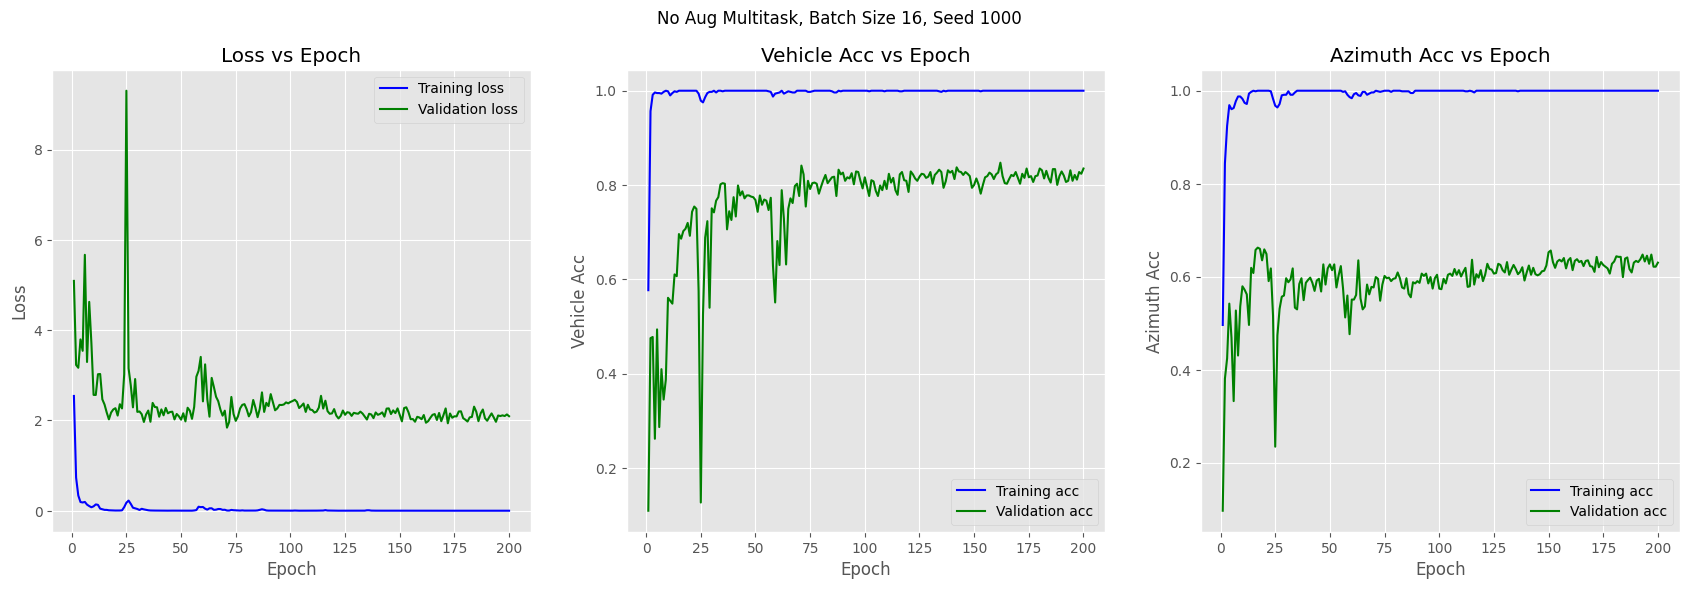

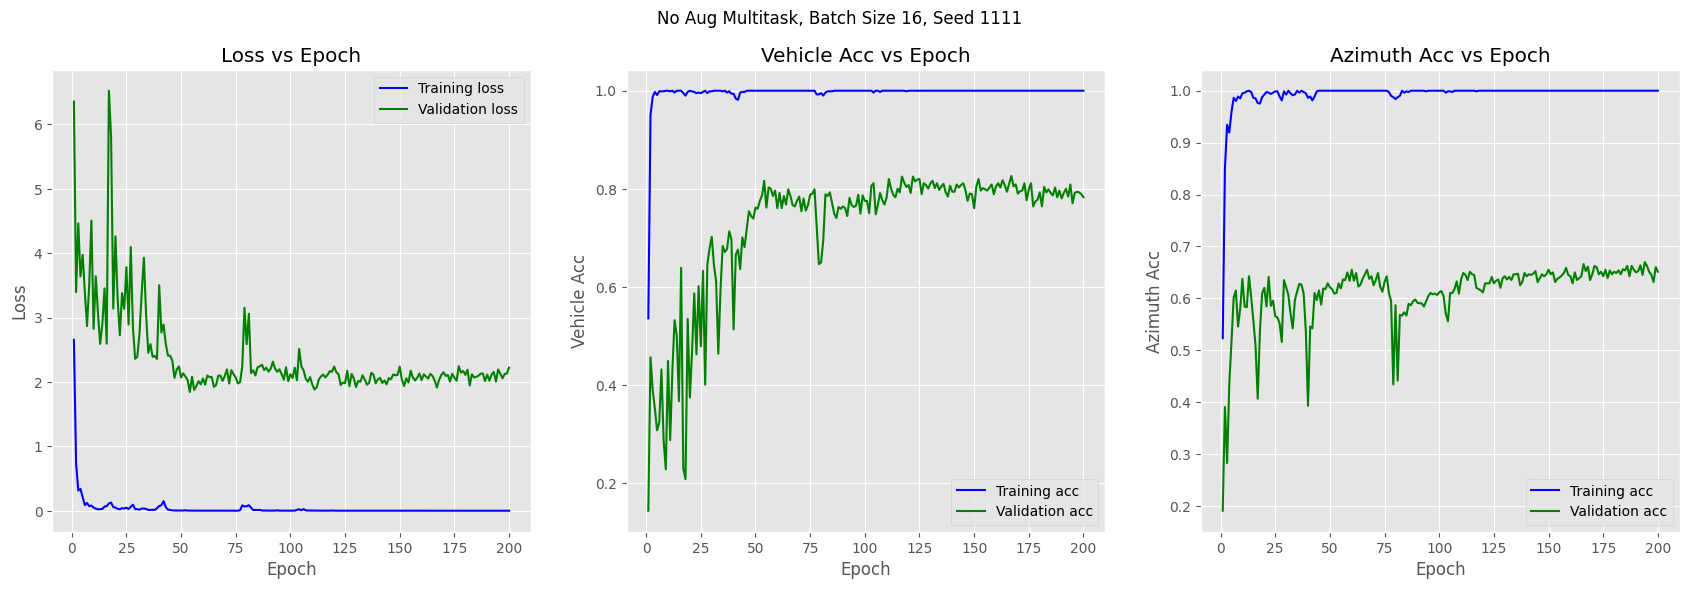

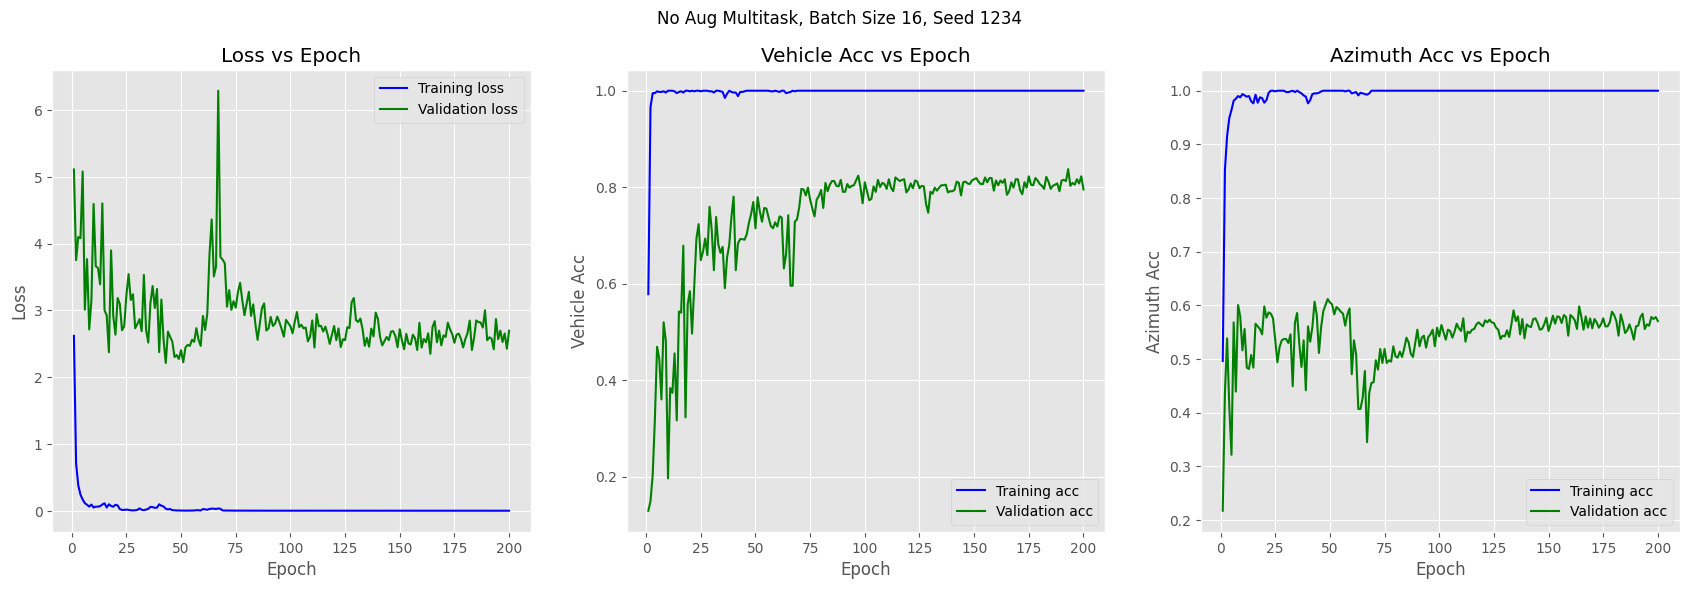

In [15]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (21, 6))
    
        ax0 = fig.add_subplot(1, 3, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 3, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_vehicle_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_vehicle_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Vehicle Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Vehicle Acc")
        ax1.legend()
        ax1.grid(True)

        ax2 = fig.add_subplot(1, 3, 3)
        ax2.plot(np.arange(1, num_epochs+1), train_azimuth_acc[i, :], label = "Training acc", c = "blue")
        ax2.plot(np.arange(1, num_epochs+1), val_azimuth_acc[i, :], label = "Validation acc", c = "green")
        ax2.set_title("Azimuth Acc vs Epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Azimuth Acc")
        ax2.legend()
        ax2.grid(True)
        
        fig.suptitle(f"No Aug Multitask, Batch Size 16, Seed {seed}")
        plt.show()

In [17]:
test_dataloader = DataLoader(multitask_test_ds, batch_size=32, shuffle=False, 
                            num_workers=8, pin_memory=True, persistent_workers=True, 
                            prefetch_factor=4)

seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    
    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/multitask/wo_aug/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    model = model.to(device)
    model.eval()

    n_test = dataset_sizes["test"]
    vehicle_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    vehicle_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    
    idx = 0
    with torch.no_grad():
        for inputs, vehicle_labels, azimuth_labels in test_dataloader:
            inputs = inputs.to(device)
            vehicle_labels = vehicle_labels.to(device)
            azimuth_labels = azimuth_labels.to(device)
    
            vehicle_logits, azimuth_logits = model(inputs)
            _, vehicle_preds = torch.max(vehicle_logits, 1)
            _, azimuth_preds = torch.max(azimuth_logits, 1)
    
            batch_size = vehicle_labels.size(0)
            vehicle_labels_tensor[idx : idx + batch_size] = vehicle_labels
            vehicle_preds_tensor[idx : idx + batch_size] = vehicle_preds
            azimuth_labels_tensor[idx : idx + batch_size] = azimuth_labels
            azimuth_preds_tensor[idx : idx + batch_size] = azimuth_preds
            idx += batch_size

    torch.cuda.synchronize()
    
    test_veh_acc = (vehicle_labels_tensor == vehicle_preds_tensor).float().mean()
    test_azimuth_acc = (azimuth_labels_tensor == azimuth_preds_tensor).float().mean()
    test_acc = ((vehicle_labels_tensor == vehicle_preds_tensor) & (azimuth_labels_tensor == azimuth_preds_tensor)).float().mean()
    print(f"Test Vehicle Accuracy: {test_veh_acc *100:.4f}\nTest Azimuth Accuracy: {test_azimuth_acc * 100:.4f}\nTest Joint Accuracy: {test_acc * 100:.4f}\n")
    test_acc_lst.append(test_acc.item())

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Vehicle Accuracy: 78.4787
Test Azimuth Accuracy: 56.0297
Test Joint Accuracy: 43.9703

Evaluating Run 1 with seed 42
Test Vehicle Accuracy: 75.1391
Test Azimuth Accuracy: 51.3915
Test Joint Accuracy: 37.1058

Evaluating Run 2 with seed 100
Test Vehicle Accuracy: 74.0260
Test Azimuth Accuracy: 46.9388
Test Joint Accuracy: 33.7662

Evaluating Run 3 with seed 123
Test Vehicle Accuracy: 77.5510
Test Azimuth Accuracy: 58.4416
Test Joint Accuracy: 44.3414

Evaluating Run 4 with seed 666
Test Vehicle Accuracy: 71.7996
Test Azimuth Accuracy: 57.8850
Test Joint Accuracy: 41.0019

Evaluating Run 5 with seed 777
Test Vehicle Accuracy: 82.7458
Test Azimuth Accuracy: 61.7811
Test Joint Accuracy: 49.3507

Evaluating Run 6 with seed 849
Test Vehicle Accuracy: 72.5417
Test Azimuth Accuracy: 61.2245
Test Joint Accuracy: 43.7848

Evaluating Run 7 with seed 1000
Test Vehicle Accuracy: 78.1076
Test Azimuth Accuracy: 60.4824
Test Joint Accuracy: 45.6401

Evaluating Run 8 